# UK Electricity Price Forecasting
## Multi-City Random Forest Model + Streamlit Dashboard

This notebook:
1. Trains a Random Forest on hourly UK electricity prices + London historical weather
2. Fetches **live weather** from the Open-Meteo API for **8 UK cities** simultaneously
3. Generates next-day price forecasts for each city using that city's local weather
4. Saves all results to a JSON file that the Streamlit dashboard reads

**Why different cities get different forecasts:**
The UK electricity price is a national wholesale price, but each city contributes
differently to demand. A cold Birmingham winter morning drives more heating demand
than a mild Cardiff afternoon. The model uses each city's local weather (temperature,
wind, solar radiation) as features alongside the national price history.

**Files produced:**
- `rf_model.pkl` - trained Random Forest
- `feature_cols.json` - 37 feature names
- `price_history.csv` - last 200h of UK prices (for lag features)
- `city_forecasts.json` - next-day forecasts for all cities (Streamlit reads this)


## Step 1 -- Setup

In [1]:
import io
import json
import pickle
import time
import warnings
from urllib.error import URLError
from urllib.parse import urlencode
from urllib.request import urlopen

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#e5e7eb", "axes.grid": True,
    "grid.color": "#f3f4f6", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlepad": 10, "figure.dpi": 120,
})

BLUE, AMBER, GREEN, RED, GREY = "#2563eb","#d97706","#16a34a","#dc2626","#9ca3af"

# The 8 UK cities used for predictions
# Spread across England, Scotland, Wales, Northern Ireland
UK_CITIES = [
    {"name": "London",     "lat": 51.5074,  "lon": -0.1278,  "region": "England"},
    {"name": "Manchester", "lat": 53.4808,  "lon": -2.2426,  "region": "England"},
    {"name": "Birmingham", "lat": 52.4862,  "lon": -1.8904,  "region": "England"},
    {"name": "Leeds",      "lat": 53.8008,  "lon": -1.5491,  "region": "England"},
    {"name": "Bristol",    "lat": 51.4545,  "lon": -2.5879,  "region": "England"},
    {"name": "Edinburgh",  "lat": 55.9533,  "lon": -3.1883,  "region": "Scotland"},
    {"name": "Cardiff",    "lat": 51.4816,  "lon": -3.1791,  "region": "Wales"},
    {"name": "Belfast",    "lat": 54.5973,  "lon": -5.9301,  "region": "N. Ireland"},
]

print(f"Cities loaded: {len(UK_CITIES)}")
for c in UK_CITIES:
    print(f"  {c['name']:<12} {c['region']:<12} lat={c['lat']:>7.4f}  lon={c['lon']:>8.4f}")


Cities loaded: 8
  London       England      lat=51.5074  lon= -0.1278
  Manchester   England      lat=53.4808  lon= -2.2426
  Birmingham   England      lat=52.4862  lon= -1.8904
  Leeds        England      lat=53.8008  lon= -1.5491
  Bristol      England      lat=51.4545  lon= -2.5879
  Edinburgh    Scotland     lat=55.9533  lon= -3.1883
  Cardiff      Wales        lat=51.4816  lon= -3.1791
  Belfast      N. Ireland   lat=54.5973  lon= -5.9301


## Step 2 -- Load Electricity Price Data

Load the hourly UK electricity prices. This is the national wholesale price --
the same value for all cities.


In [2]:
# UPDATE THIS PATH
ELEC_PATH = "UK_Electricity_values_cleaned.csv"

elec = pd.read_csv(ELEC_PATH)
elec["dt"] = pd.to_datetime(elec["Datetime (Local)"], dayfirst=True)
elec = (elec.rename(columns={"Price (EUR/MWhe)": "price"})
            [["dt", "price"]]
            .sort_values("dt")
            .reset_index(drop=True))

print(f"Electricity rows:  {len(elec):,}")
print(f"Date range:        {elec.dt.min().date()} to {elec.dt.max().date()}")
print(f"Price range:       {elec.price.min():.1f} to {elec.price.max():.1f} EUR/MWh")
print(f"Mean price:        {elec.price.mean():.1f} EUR/MWh")
elec.tail(4)


Electricity rows:  84,817
Date range:        2016-06-30 to 2026-03-03
Price range:       -60.2 to 2575.9 EUR/MWh
Mean price:        94.6 EUR/MWh


,dt,price
84813,2026-03-03 20:00:00,112.72
84814,2026-03-03 21:00:00,106.60
84815,2026-03-03 22:00:00,101.22
84816,2026-03-03 23:00:00,130.15


## Step 3 -- Load Historical Weather (Training Data)

The model is **trained** using London weather data from 2016-2026.
At prediction time (Step 7), each city's own live weather is used instead.

This is acceptable because:
- Weather features contribute only ~9% of total feature importance
- The dominant features (60%+) are price lags -- the same national price for all cities
- Training on London weather teaches the model the general weather-demand relationship
- Local city weather then personalises predictions at inference time


In [3]:
LONDON = {"lat": 51.5074, "lon": -0.1278}

def fetch_historical_weather(lat, lon, start_date, end_date, timezone="Europe/London"):
    variables = ",".join([
        "temperature_2m", "precipitation",
        "wind_speed_10m", "shortwave_radiation",
        "relative_humidity_2m",
    ])
    chunks = []
    current = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    while current <= end:
        chunk_end = min(current + pd.DateOffset(years=1) - pd.Timedelta(days=1), end)
        params = urlencode({
            "latitude":   lat,
            "longitude":  lon,
            "start_date": current.strftime("%Y-%m-%d"),
            "end_date":   chunk_end.strftime("%Y-%m-%d"),
            "hourly":     variables,
            "timezone":   timezone,
        })
        url = f"https://archive-api.open-meteo.com/v1/archive?{params}"
        print(f"  Fetching {current.date()} to {chunk_end.date()}...", end=" ")
        try:
            with urlopen(url, timeout=60) as resp:
                data = json.loads(resp.read())
            h = data["hourly"]
            df_chunk = pd.DataFrame({
                "dt":       pd.to_datetime(h["time"]),
                "temp":     h["temperature_2m"],
                "precip":   h["precipitation"],
                "wind":     h["wind_speed_10m"],
                "solar":    h["shortwave_radiation"],
                "humidity": h["relative_humidity_2m"],
            })
            chunks.append(df_chunk)
            print(f"OK ({len(df_chunk)} rows)")
        except Exception as e:
            print(f"FAILED: {e}")
        current = chunk_end + pd.Timedelta(days=1)
        time.sleep(0.5)
    if not chunks:
        raise RuntimeError("Failed to fetch any historical weather data from Open-Meteo")
    df = pd.concat(chunks, ignore_index=True)
    return df.sort_values("dt").reset_index(drop=True)

start_date = elec["dt"].min().strftime("%Y-%m-%d")
end_date   = elec["dt"].max().strftime("%Y-%m-%d")

print(f"Fetching London historical weather: {start_date} to {end_date}")
print("(Fetching ~10 years in annual chunks -- takes about 30-60 seconds)")
weather_hist = fetch_historical_weather(LONDON["lat"], LONDON["lon"], start_date, end_date)
print(f"\nHistorical weather rows: {len(weather_hist):,}")
print(f"Date range: {weather_hist.dt.min().date()} to {weather_hist.dt.max().date()}")
print(f"Variables:  {list(weather_hist.columns)}")


Fetching London historical weather: 2016-06-30 to 2026-03-03
(Fetching ~10 years in annual chunks -- takes about 30-60 seconds)
  Fetching 2016-06-30 to 2017-06-29... OK (8760 rows)
  Fetching 2017-06-30 to 2018-06-29... OK (8760 rows)
  Fetching 2018-06-30 to 2019-06-29... OK (8760 rows)
  Fetching 2019-06-30 to 2020-06-29... OK (8784 rows)
  Fetching 2020-06-30 to 2021-06-29... OK (8760 rows)
  Fetching 2021-06-30 to 2022-06-29... OK (8760 rows)
  Fetching 2022-06-30 to 2023-06-29... OK (8760 rows)
  Fetching 2023-06-30 to 2024-06-29... OK (8784 rows)
  Fetching 2024-06-30 to 2025-06-29... OK (8760 rows)
  Fetching 2025-06-30 to 2026-03-03... OK (5928 rows)

Historical weather rows: 84,816
Date range: 2016-06-30 to 2026-03-03
Variables:  ['dt', 'temp', 'precip', 'wind', 'solar', 'humidity']


## Step 4 -- Feature Engineering

Builds all 37 features from hourly price + weather data.
The target is the price at the same hour tomorrow (24h ahead).
All lag features use data >= 24h old -- no data leakage.


In [4]:
FCOLS = [
    "hour","dow","month","is_weekend","is_peak",
    "sin_h1","cos_h1","sin_h2","cos_h2","sin_h3","cos_h3",
    "sin_d1","cos_d1","sin_d2","cos_d2",
    "sin_m1","cos_m1","sin_m2","cos_m2",
    "p_lag24","p_lag48","p_lag168",
    "p_roll_mean24","p_roll_std24","p_roll_mean168",
    "p_roll_min24","p_roll_max24","vol_regime",
    "temp","wind","solar","humidity","precip",
    "hdd","wind_sq","temp_lag24","wind_lag24",
]

def build_features(price_df, weather_df):
    """
    Merge electricity prices with hourly weather and compute all 37 features.

    price_df:   DataFrame with [dt, price]
    weather_df: DataFrame with [dt, temp, wind, solar, humidity, precip]

    Returns (df_model, FCOLS) where df_model has all features + target column.
    """
    df = price_df.merge(weather_df, on="dt", how="left").sort_values("dt").reset_index(drop=True)

    # Fill minor weather gaps
    for col in ["temp","wind","solar","humidity","precip"]:
        if col not in df.columns:
            df[col] = 0.0
        else:
            df[col] = df[col].ffill().bfill().fillna(0.0)

    # Calendar
    df["hour"]       = df["dt"].dt.hour
    df["dow"]        = df["dt"].dt.dayofweek
    df["month"]      = df["dt"].dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["is_peak"]    = df["hour"].isin([7,8,9,16,17,18,19]).astype(int)

    # Fourier -- cyclic encoding so hour 23 and hour 0 are adjacent
    for k in [1,2,3]:
        df[f"sin_h{k}"] = np.sin(2*np.pi*k*df["hour"]/24)
        df[f"cos_h{k}"] = np.cos(2*np.pi*k*df["hour"]/24)
    for k in [1,2]:
        df[f"sin_d{k}"] = np.sin(2*np.pi*k*df["dow"]/7)
        df[f"cos_d{k}"] = np.cos(2*np.pi*k*df["dow"]/7)
        df[f"sin_m{k}"] = np.sin(2*np.pi*k*df["month"]/12)
        df[f"cos_m{k}"] = np.cos(2*np.pi*k*df["month"]/12)

    # Price lags -- all >= 24h to prevent leakage into target
    for lag in [24, 48, 168]:
        df[f"p_lag{lag}"] = df["price"].shift(lag)

    # Rolling statistics -- shift 24h first so no same-day price is used
    p24 = df["price"].shift(24)
    df["p_roll_mean24"]  = p24.rolling(24).mean()
    df["p_roll_std24"]   = p24.rolling(24).std()
    df["p_roll_mean168"] = p24.rolling(168).mean()
    df["p_roll_min24"]   = p24.rolling(24).min()
    df["p_roll_max24"]   = p24.rolling(24).max()

    std24  = p24.rolling(24).std()
    std168 = p24.rolling(168).std()
    df["vol_regime"] = (std24 / std168.replace(0, np.nan)).fillna(1.0).clip(0, 5)

    # Derived weather
    df["hdd"]        = np.maximum(0, 15.5 - df["temp"])   # heating degree hours
    df["wind_sq"]    = df["wind"] ** 2                     # wind generation proxy
    df["temp_lag24"] = df["temp"].shift(24)
    df["wind_lag24"] = df["wind"].shift(24)

    # Target: same-hour price tomorrow
    df["target"] = df["price"].shift(-24)

    df_model = df.dropna(subset=FCOLS + ["target"]).copy().reset_index(drop=True)
    return df_model

df = build_features(elec, weather_hist)
print(f"Feature matrix: {len(df):,} rows x {len(FCOLS)} features")
print(f"Date range:     {df.dt.min().date()} to {df.dt.max().date()}")


Feature matrix: 84,602 rows x 37 features
Date range:     2016-07-07 to 2026-03-02


## Step 5 -- Quick Exploratory Analysis

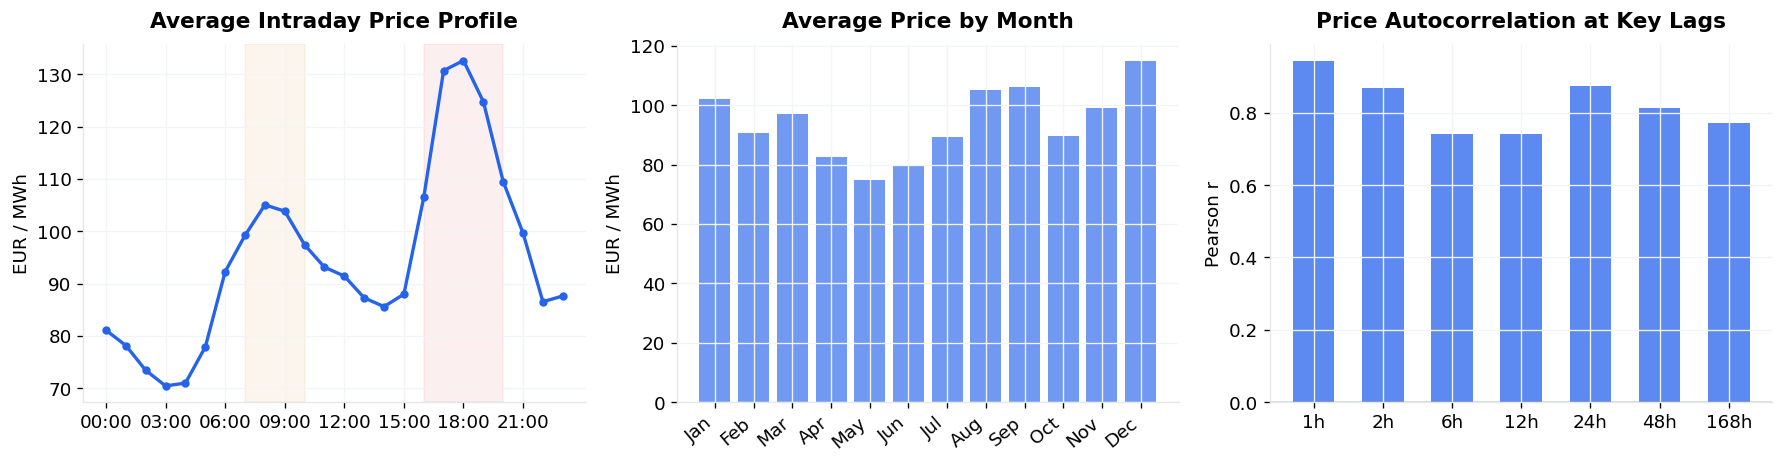

Peak hour: 18:00  (132.6 EUR/MWh)
Lag-24h autocorrelation: 0.874  (dominant predictor)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Intraday profile
hourly_avg = df.groupby("hour")["price"].mean()
axes[0].plot(range(24), hourly_avg.values, color=BLUE, linewidth=2,
             marker="o", markersize=4)
axes[0].axvspan(7, 10, alpha=0.07, color=AMBER)
axes[0].axvspan(16, 20, alpha=0.07, color=RED)
axes[0].set_xticks(range(0,24,3))
axes[0].set_xticklabels([f"{h:02d}:00" for h in range(0,24,3)])
axes[0].set_title("Average Intraday Price Profile")
axes[0].set_ylabel("EUR / MWh")

# Seasonality
month_avg = df.groupby("month")["price"].mean()
mon = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(range(12), month_avg.values, color=BLUE, alpha=0.65)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(mon, rotation=40, ha="right")
axes[1].set_title("Average Price by Month")
axes[1].set_ylabel("EUR / MWh")

# Autocorrelation at key lags
lags = [1,2,6,12,24,48,168]
acf  = [df["price"].autocorr(lag=l) for l in lags]
axes[2].bar([str(l)+"h" for l in lags], acf,
            color=[BLUE if abs(v)>0.5 else GREY for v in acf],
            alpha=0.75, width=0.6)
axes[2].axhline(0, color="#374151", linewidth=0.8)
axes[2].set_title("Price Autocorrelation at Key Lags")
axes[2].set_ylabel("Pearson r")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Peak hour: {hourly_avg.idxmax():02d}:00  ({hourly_avg.max():.1f} EUR/MWh)")
print(f"Lag-24h autocorrelation: {acf[lags.index(24)]:.3f}  (dominant predictor)")


## Step 6 -- Train the Random Forest

Temporal split: train on 2016-2023, evaluate on 2024-2026.


In [15]:
SPLIT = pd.Timestamp("2024-01-01")
X = df[FCOLS]
y = df["target"]
tr = df["dt"] < SPLIT
te = df["dt"] >= SPLIT

print(f"Training: {tr.sum():,} hours  ({df[tr].dt.min().date()} to {df[tr].dt.max().date()})")
print(f"Test:     {te.sum():,} hours  ({df[te].dt.min().date()} to {df[te].dt.max().date()})")
print()
print("Training Random Forest (n=150, depth=12) -- approx 2 minutes...")

rf = RandomForestRegressor(
    n_estimators     = 150,
    max_depth        = 12,
    min_samples_leaf = 8,
    max_features     = 0.7,
    random_state     = 42,
)
rf.fit(X[tr], y[tr])
print("Training complete.")


Training: 65,594 hours  (2016-07-07 to 2023-12-31)
Test:     19,008 hours  (2024-01-01 to 2026-03-02)

Training Random Forest (n=150, depth=12) -- approx 2 minutes...
Training complete.


In [16]:
# Evaluate on test set
preds_te = rf.predict(X[te])
act_te   = y[te].values

mae  = mean_absolute_error(act_te, preds_te)
rmse = np.sqrt(mean_squared_error(act_te, preds_te))
r2   = r2_score(act_te, preds_te)

# MAPE -- exclude near-zero prices to avoid division issues
nz   = np.abs(act_te) > 5
mape = np.mean(np.abs((act_te[nz]-preds_te[nz])/act_te[nz]))*100

print("Test set performance (Jan 2024 - Mar 2026):")
print(f"  MAE:  {mae:.2f} EUR/MWh")
print(f"  RMSE: {rmse:.2f} EUR/MWh")
print(f"  R2:   {r2:.3f}  ({r2*100:.0f}% of variance explained)")
print(f"  MAPE: {mape:.1f}%  (prices > 5 EUR/MWh only)")


Test set performance (Jan 2024 - Mar 2026):
  MAE:  18.13 EUR/MWh
  RMSE: 30.69 EUR/MWh
  R2:   0.371  (37% of variance explained)
  MAPE: 38.8%  (prices > 5 EUR/MWh only)


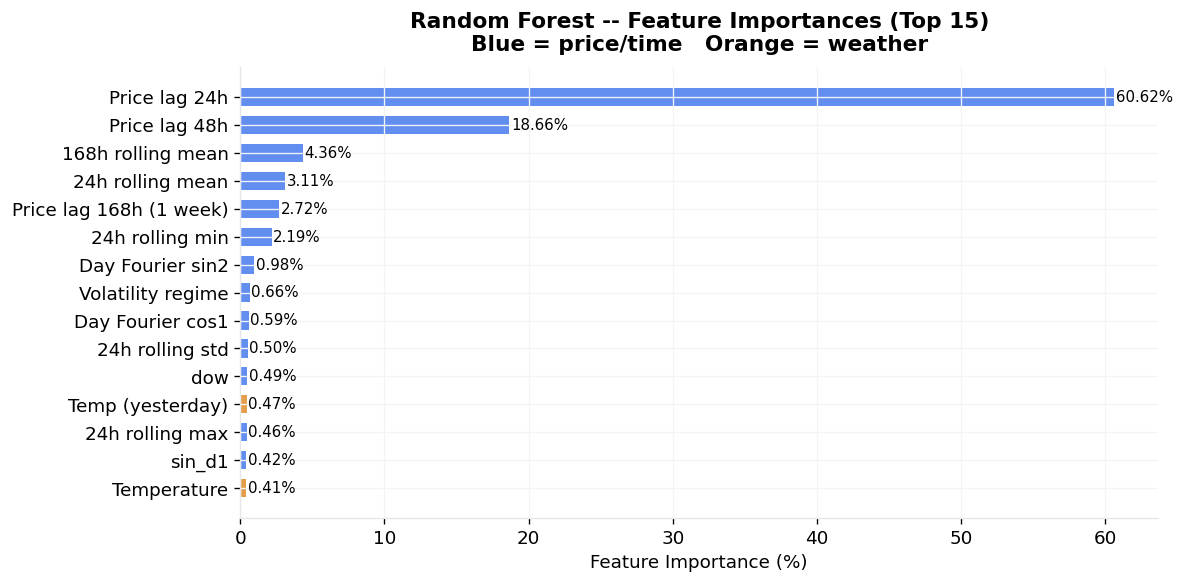

Weather features total importance: 2.4%
Price/time features:               97.6%


In [17]:
# Feature importances
fi = (pd.DataFrame({"feature": FCOLS, "importance": rf.feature_importances_})
        .sort_values("importance", ascending=False))

WX = {"wind","wind_sq","wind_lag24","temp","temp_lag24","hdd","solar","humidity","precip"}
NAME = {
    "p_lag24":"Price lag 24h", "p_lag48":"Price lag 48h",
    "p_lag168":"Price lag 168h (1 week)", "p_roll_mean24":"24h rolling mean",
    "p_roll_std24":"24h rolling std", "p_roll_mean168":"168h rolling mean",
    "p_roll_min24":"24h rolling min", "p_roll_max24":"24h rolling max",
    "vol_regime":"Volatility regime", "wind":"Wind speed", "wind_sq":"Wind^2",
    "wind_lag24":"Wind (yesterday)", "temp":"Temperature", "temp_lag24":"Temp (yesterday)",
    "hdd":"Heating degree hours", "solar":"Solar radiation", "humidity":"Humidity",
    "sin_h1":"Hour Fourier sin1", "cos_d1":"Day Fourier cos1",
    "sin_d2":"Day Fourier sin2", "is_peak":"Is peak hour", "is_weekend":"Is weekend",
}
fi["label"] = fi["feature"].map(NAME).fillna(fi["feature"])
top15 = fi.head(15)

fig, ax = plt.subplots(figsize=(10, 5))
cols = [AMBER if f in WX else BLUE for f in top15["feature"]]
bars = ax.barh(top15["label"], top15["importance"]*100, color=cols, alpha=0.72, height=0.65)
ax.set_xlabel("Feature Importance (%)")
ax.set_title("Random Forest -- Feature Importances (Top 15)\nBlue = price/time   Orange = weather")
ax.invert_yaxis()
for bar, val in zip(bars, top15["importance"]*100):
    ax.text(val+0.1, bar.get_y()+bar.get_height()/2, f"{val:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

wx_total = fi[fi["feature"].isin(WX)]["importance"].sum()*100
print(f"Weather features total importance: {wx_total:.1f}%")
print(f"Price/time features:               {100-wx_total:.1f}%")


## Step 7 -- Save Model Artifacts

In [18]:
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)
with open("feature_cols.json", "w") as f:
    json.dump(FCOLS, f)

# Save last 200 hours of price data for lag features at prediction time
elec.tail(200).to_csv("price_history.csv", index=False)

import os
for fname in ["rf_model.pkl","feature_cols.json","price_history.csv"]:
    size = os.path.getsize(fname)
    print(f"  {fname:<25} {size/1024:.0f} KB")
print("Model artifacts saved.")


  rf_model.pkl              22107 KB
  feature_cols.json         0 KB
  price_history.csv         5 KB
Model artifacts saved.


## Step 8 -- Live Weather API

Fetches current + forecast hourly weather for all 8 UK cities from Open-Meteo.
Free, no API key required.

`past_days=8` ensures we always have enough data to compute the 168-hour lag features.


In [19]:
def fetch_city_weather(city):
    """
    Fetch past 8 days + 2 forecast days of hourly weather for a city.
    Returns DataFrame [dt, temp, precip, wind, solar, humidity] or None on failure.
    """
    variables = ",".join([
        "temperature_2m", "precipitation",
        "wind_speed_10m", "shortwave_radiation",
        "relative_humidity_2m",
    ])
    params = urlencode({
        "latitude":      city["lat"],
        "longitude":     city["lon"],
        "hourly":        variables,
        "past_days":     8,
        "forecast_days": 2,
        "timezone":      "Europe/London",
    })
    url = f"https://api.open-meteo.com/v1/forecast?{params}"
    try:
        with urlopen(url, timeout=15) as resp:
            data = json.loads(resp.read())
        h = data["hourly"]
        df = pd.DataFrame({
            "dt":       pd.to_datetime(h["time"]),
            "temp":     h["temperature_2m"],
            "precip":   h["precipitation"],
            "wind":     h["wind_speed_10m"],
            "solar":    h["shortwave_radiation"],
            "humidity": h["relative_humidity_2m"],
        })
        return df.sort_values("dt").reset_index(drop=True)
    except Exception as e:
        print(f"    Warning -- could not fetch weather for {city['name']}: {e}")
        return None


def fetch_all_cities(cities, delay=0.5):
    """
    Fetch weather for all cities with a small delay between requests
    to be polite to the free API.
    """
    results = {}
    for city in cities:
        print(f"  Fetching weather for {city['name']}...", end=" ")
        wx = fetch_city_weather(city)
        if wx is not None:
            results[city["name"]] = wx
            print(f"OK  ({len(wx)} rows, {wx.dt.min().date()} to {wx.dt.max().date()})")
        else:
            print("FAILED")
        time.sleep(delay)
    return results

print("Fetching live weather for all UK cities...")
city_weather = fetch_all_cities(UK_CITIES)
print(f"\nSuccessfully fetched weather for {len(city_weather)}/{len(UK_CITIES)} cities.")


Fetching live weather for all UK cities...
  Fetching weather for London... OK  (240 rows, 2026-04-20 to 2026-04-29)
  Fetching weather for Manchester... OK  (240 rows, 2026-04-20 to 2026-04-29)
  Fetching weather for Birmingham... OK  (240 rows, 2026-04-20 to 2026-04-29)
  Fetching weather for Leeds... OK  (240 rows, 2026-04-20 to 2026-04-29)
  Fetching weather for Bristol... OK  (240 rows, 2026-04-20 to 2026-04-29)
  Fetching weather for Edinburgh... OK  (240 rows, 2026-04-20 to 2026-04-29)
  Fetching weather for Cardiff... OK  (240 rows, 2026-04-20 to 2026-04-29)
  Fetching weather for Belfast... OK  (240 rows, 2026-04-20 to 2026-04-29)

Successfully fetched weather for 8/8 cities.


## Step 9 -- Build Prediction Features Per City

For each city, merge the national price history with that city's local weather
and compute all 37 features. The last 24 rows (today's hours) are used to
predict tomorrow's 24 hourly prices.


In [20]:
price_history = pd.read_csv("price_history.csv", parse_dates=["dt"])


def predict_city(city_name, city_weather_df, price_hist, model, fcols):
    """
    Build features for a city and predict next-day hourly prices.

    city_weather_df: live weather for this city (past 8d + 2d forecast)
    price_hist:      last 200 hours of national UK electricity prices
    model:           trained Random Forest
    fcols:           list of 37 feature column names

    Returns DataFrame [pred_dt, hour, price, temp, wind, solar, humidity]
    """
    # Outer merge so tomorrow's weather hours are included
    df = (price_hist
          .merge(city_weather_df, on="dt", how="outer")
          .sort_values("dt")
          .reset_index(drop=True))

    # Fill gaps
    for col in ["temp","wind","solar","humidity","precip"]:
        if col not in df.columns:
            df[col] = 0.0
        else:
            df[col] = df[col].ffill().bfill().fillna(0.0)

    # Calendar
    df["hour"]       = df["dt"].dt.hour
    df["dow"]        = df["dt"].dt.dayofweek
    df["month"]      = df["dt"].dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["is_peak"]    = df["hour"].isin([7,8,9,16,17,18,19]).astype(int)

    for k in [1,2,3]:
        df[f"sin_h{k}"] = np.sin(2*np.pi*k*df["hour"]/24)
        df[f"cos_h{k}"] = np.cos(2*np.pi*k*df["hour"]/24)
    for k in [1,2]:
        df[f"sin_d{k}"] = np.sin(2*np.pi*k*df["dow"]/7)
        df[f"cos_d{k}"] = np.cos(2*np.pi*k*df["dow"]/7)
        df[f"sin_m{k}"] = np.sin(2*np.pi*k*df["month"]/12)
        df[f"cos_m{k}"] = np.cos(2*np.pi*k*df["month"]/12)

    for lag in [24,48,168]:
        df[f"p_lag{lag}"] = df["price"].shift(lag)

    p24 = df["price"].shift(24)
    df["p_roll_mean24"]  = p24.rolling(24).mean()
    df["p_roll_std24"]   = p24.rolling(24).std()
    df["p_roll_mean168"] = p24.rolling(168).mean()
    df["p_roll_min24"]   = p24.rolling(24).min()
    df["p_roll_max24"]   = p24.rolling(24).max()

    std24  = p24.rolling(24).std()
    std168 = p24.rolling(168).std()
    df["vol_regime"] = (std24 / std168.replace(0, np.nan)).fillna(1.0).clip(0, 5)

    df["hdd"]        = np.maximum(0, 15.5 - df["temp"])
    df["wind_sq"]    = df["wind"] ** 2
    df["temp_lag24"] = df["temp"].shift(24)
    df["wind_lag24"] = df["wind"].shift(24)

    # Get the 24 rows with complete features (these are today's hours)
    feats = df.dropna(subset=fcols).tail(24).copy().reset_index(drop=True)
    if len(feats) < 24:
        return None

    prices = model.predict(feats[fcols])
    pred_dts = feats["dt"] + pd.Timedelta(hours=24)

    return pd.DataFrame({
        "pred_dt":  pred_dts,
        "hour":     pred_dts.dt.hour,
        "price":    np.round(prices, 2),
        "temp":     feats["temp"].values.round(1),
        "wind":     feats["wind"].values.round(1),
        "solar":    feats["solar"].values.round(1),
        "humidity": feats["humidity"].values.round(1),
    })


print("Running predictions for all cities...")
city_forecasts = {}

for city in UK_CITIES:
    name = city["name"]
    if name not in city_weather:
        print(f"  {name:<12} SKIPPED (no weather data)")
        continue
    fc = predict_city(name, city_weather[name], price_history, rf, FCOLS)
    if fc is not None:
        city_forecasts[name] = fc
        pred_date = fc["pred_dt"].iloc[0].strftime("%Y-%m-%d")
        print(f"  {name:<12} OK  mean={fc.price.mean():.1f}  "
              f"peak={fc.price.max():.1f}@{int(fc.loc[fc.price.idxmax(),'hour']):02d}:00  "
              f"date={pred_date}")
    else:
        print(f"  {name:<12} FAILED (not enough lag data)")

print(f"\nForecasts ready for {len(city_forecasts)} cities.")


Running predictions for all cities...
  London       OK  mean=103.2  peak=157.4@17:00  date=2026-04-21
  Manchester   OK  mean=103.6  peak=157.4@17:00  date=2026-04-21
  Birmingham   OK  mean=104.1  peak=157.6@17:00  date=2026-04-21
  Leeds        OK  mean=103.5  peak=156.9@17:00  date=2026-04-21
  Bristol      OK  mean=103.8  peak=158.7@17:00  date=2026-04-21
  Edinburgh    OK  mean=102.6  peak=154.9@17:00  date=2026-04-21
  Cardiff      OK  mean=103.1  peak=155.5@17:00  date=2026-04-21
  Belfast      OK  mean=102.4  peak=151.4@17:00  date=2026-04-21

Forecasts ready for 8 cities.


## Step 10 -- Print Forecast Results

In [21]:
# Print full table for each city
for city in UK_CITIES:
    name = city["name"]
    if name not in city_forecasts:
        continue
    fc = city_forecasts[name]
    pred_date = fc["pred_dt"].iloc[0].strftime("%A %d %B %Y")
    print(f"{'='*58}")
    print(f"  {name.upper()} -- {pred_date}")
    print(f"{'='*58}")
    print(f"  {'Hour':<8} {'Price':>10} {'Temp':>8} {'Wind':>8} {'Solar':>8}")
    print(f"  {'-'*50}")
    for _, row in fc.iterrows():
        bar = "|" * int(row.price / 10)
        print(f"  {int(row.hour):02d}:00   {row.price:>8.2f}  "
              f"{row.temp:>6.1f}C  {row.wind:>5.1f}km/h  {row.solar:>6.0f}W  {bar}")
    print(f"  Mean:  {fc.price.mean():.2f} EUR/MWh")
    print(f"  Peak:  {fc.price.max():.2f} EUR/MWh @ {int(fc.loc[fc.price.idxmax(),'hour']):02d}:00")
    print(f"  Min:   {fc.price.min():.2f} EUR/MWh @ {int(fc.loc[fc.price.idxmin(),'hour']):02d}:00")
    print()


  LONDON -- Tuesday 21 April 2026
  Hour          Price     Temp     Wind    Solar
  --------------------------------------------------
  00:00      89.72     9.9C    7.2km/h       0W  ||||||||
  01:00      89.19     9.1C    6.8km/h       0W  ||||||||
  02:00      89.52     8.7C    7.6km/h       0W  ||||||||
  03:00      88.39     7.9C    3.6km/h       0W  ||||||||
  04:00      89.38     7.9C    4.7km/h       0W  ||||||||
  05:00      94.25     7.5C    4.7km/h       0W  |||||||||
  06:00     115.48     7.3C    5.8km/h       0W  |||||||||||
  07:00     127.54     6.9C    6.5km/h      48W  ||||||||||||
  08:00     111.80     7.7C    9.0km/h     165W  |||||||||||
  09:00     100.75     9.3C    9.4km/h     275W  ||||||||||
  10:00      90.06    10.2C    7.9km/h     459W  |||||||||
  11:00      79.03    11.4C   10.4km/h     415W  |||||||
  12:00      81.34    12.4C   11.2km/h     456W  ||||||||
  13:00      86.11    12.8C    9.7km/h     386W  ||||||||
  14:00      90.99    12.9C   10.1km/h 

## Step 11 -- Plot All City Forecasts

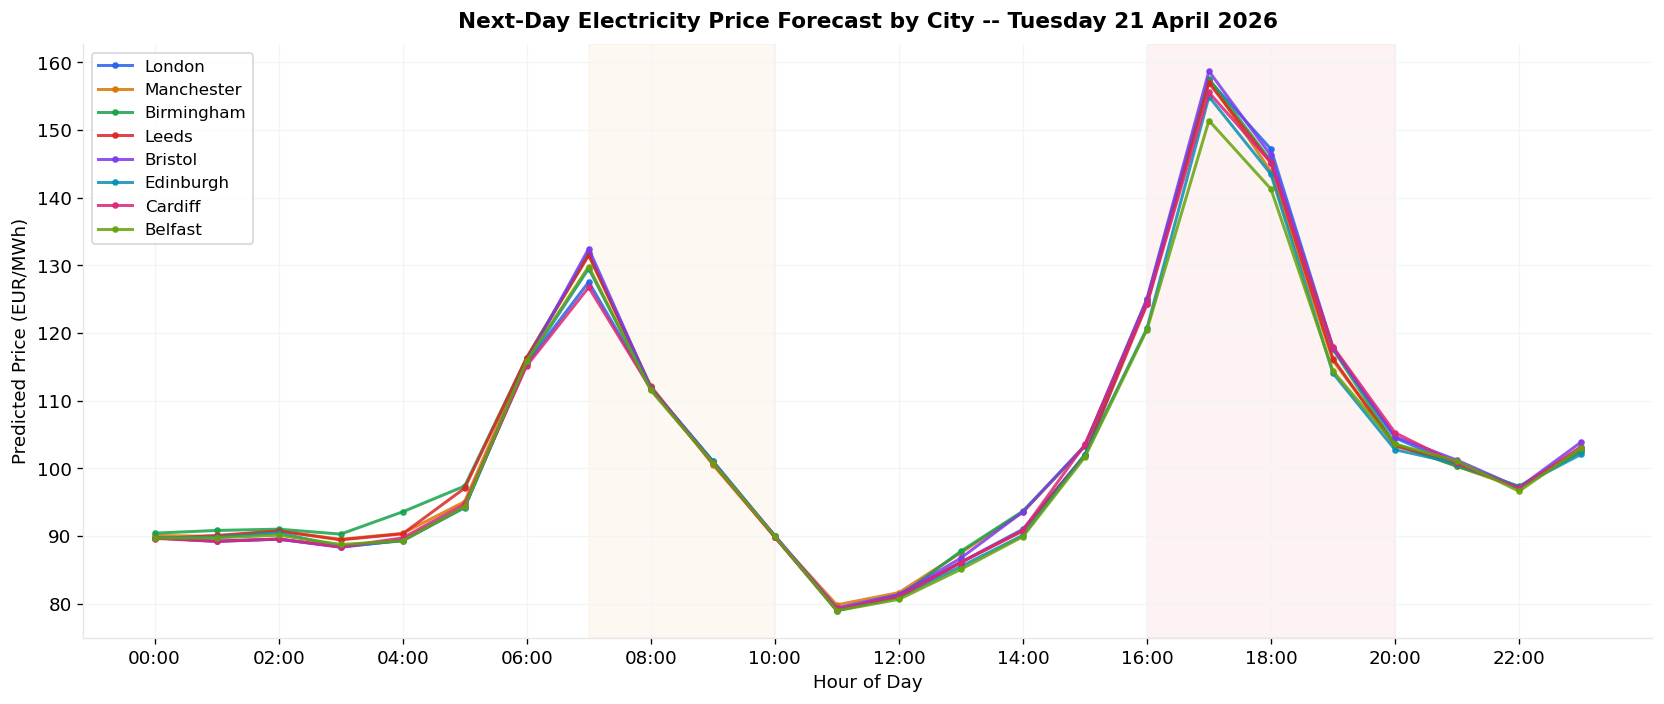

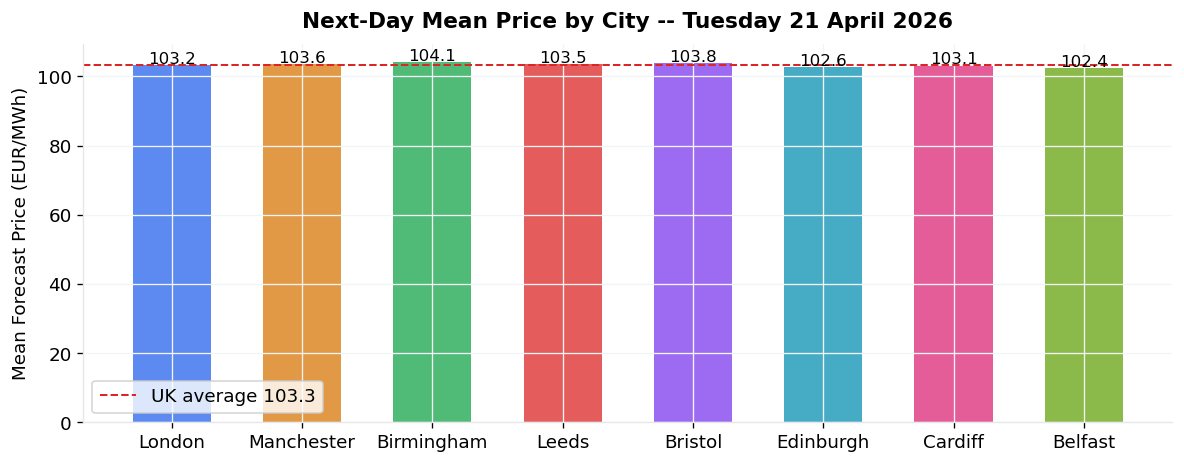

In [22]:
colors = [BLUE, AMBER, GREEN, RED, "#7c3aed", "#0891b2", "#db2777", "#65a30d"]
hours  = list(range(24))

fig, ax = plt.subplots(figsize=(14, 6))

for i, city in enumerate(UK_CITIES):
    name = city["name"]
    if name not in city_forecasts:
        continue
    fc = city_forecasts[name]
    ax.plot(hours, fc["price"].values,
            color=colors[i % len(colors)],
            linewidth=1.8, label=name, marker="o", markersize=3, alpha=0.85)

ax.axvspan(7, 10, alpha=0.05, color=AMBER)
ax.axvspan(16, 20, alpha=0.05, color=RED)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Predicted Price (EUR/MWh)")
fc_sample = list(city_forecasts.values())[0]
pred_date = fc_sample["pred_dt"].iloc[0].strftime("%A %d %B %Y")
ax.set_title(f"Next-Day Electricity Price Forecast by City -- {pred_date}")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.savefig("city_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

# City comparison bar chart
city_means = {n: city_forecasts[n]["price"].mean()
              for n in city_forecasts}
fig2, ax2 = plt.subplots(figsize=(10, 4))
names  = list(city_means.keys())
values = list(city_means.values())
bar_colors = [colors[i % len(colors)] for i in range(len(names))]
bars = ax2.bar(names, values, color=bar_colors, alpha=0.75, width=0.6)
ax2.axhline(np.mean(values), color=RED, linewidth=1.2, linestyle="--",
            label=f"UK average {np.mean(values):.1f}")
ax2.set_ylabel("Mean Forecast Price (EUR/MWh)")
ax2.set_title(f"Next-Day Mean Price by City -- {pred_date}")
ax2.legend()
for bar, val in zip(bars, values):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.5, f"{val:.1f}",
             ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("city_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 12 -- Save Results for Streamlit Dashboard

Saves `city_forecasts.json` which the Streamlit app reads automatically.
Run this cell each time you want to refresh the dashboard with new predictions.


In [23]:
def safe_float(v):
    try:
        f = float(v)
        return 0.0 if (f != f or abs(f) == float("inf")) else round(f, 2)
    except:
        return 0.0

output = {
    "generated_at":  pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "pred_date":     list(city_forecasts.values())[0]["pred_dt"].iloc[0].strftime("%Y-%m-%d"),
    "pred_date_str": list(city_forecasts.values())[0]["pred_dt"].iloc[0].strftime("%A %d %B %Y"),
    "model_mae":     round(mae, 2),
    "model_r2":      round(r2, 3),
    "cities":        [],
}

for city in UK_CITIES:
    name = city["name"]
    if name not in city_forecasts:
        continue
    fc = city_forecasts[name]
    peak_idx = fc["price"].idxmax()
    low_idx  = fc["price"].idxmin()
    output["cities"].append({
        "name":       name,
        "region":     city["region"],
        "lat":        city["lat"],
        "lon":        city["lon"],
        "mean_price": safe_float(fc["price"].mean()),
        "peak_price": safe_float(fc["price"].max()),
        "peak_hour":  int(fc.loc[peak_idx, "hour"]),
        "low_price":  safe_float(fc["price"].min()),
        "low_hour":   int(fc.loc[low_idx, "hour"]),
        "day_range":  safe_float(fc["price"].max() - fc["price"].min()),
        "hours":      [int(h) for h in fc["hour"]],
        "prices":     [safe_float(p) for p in fc["price"]],
        "temps":      [safe_float(t) for t in fc["temp"]],
        "winds":      [safe_float(w) for w in fc["wind"]],
        "solars":     [safe_float(s) for s in fc["solar"]],
    })

with open("city_forecasts.json", "w") as f:
    json.dump(output, f, indent=2)

import os
size = os.path.getsize("city_forecasts.json")
print(f"city_forecasts.json saved ({size} bytes)")
print(f"Generated at: {output['generated_at']}")
print(f"Forecast for: {output['pred_date_str']}")
print(f"Cities saved: {len(output['cities'])}")
print()
print("Run app.py to see the dashboard:  streamlit run app.py")


city_forecasts.json saved (17481 bytes)
Generated at: 2026-04-28 15:19
Forecast for: Tuesday 21 April 2026
Cities saved: 8

Run app.py to see the dashboard:  streamlit run app.py
